In [1]:
import gurobipy as gp
from gurobipy import GRB
from gurobipy import *

In [ ]:
# parameters
# Operations = [1,2,3,4,5,6,7]
Operations = [1, 2, 3, 4]
J= len(Operations)
Ressources = [1,2,3,4,5,6,7,8]
R= len(Ressources)
T= 16

predecessors = [[],             # Step 1: Station 0_Input
                [0],            # Step 2: Station 1_stearing
                [0],            # Step 2: Station 2_stearing
                [0],            # Step 2: Station 3_stearing
                [1, 2, 3],      # Step 3: Station 4_light
                [1, 2, 3],      # Step 3: Station 5_light
                [1, 2, 3],      # Step 3: Station 6_light
                [4, 5, 6]]      # Step 4: Station 7_Output

#duration = [2, 3, 2, 4, 1, 2, 1]
duration = [2, 3, 2, 1]

#demand_capacity =  [[1, 1, 2, 1, 1, 1, 4],
#                    [2, 1, 1, 2, 1, 1, 3],
#                    [1, 2, 1, 1, 1, 1, 1],
#                    [1, 2, 1, 1, 1, 1, 1],
#                    [1, 2, 3, 1, 3, 1, 2],
#                    [1, 2, 1, 1, 1, 1, 2],
#                    [3, 3, 3, 3, 3, 3, 3]]
demand_capacity= [[1, 2, 2, 1, 1, 2, 1], [1, 1, 2, 1, 1, 1, 4], [2, 1, 1, 2, 1, 1, 3], [1, 2, 1, 1, 1, 1, 1]]

FEZ= [0,0,0,0,0,0,0]
SEZ= [15,15,15,15,15,15,15] 

capacity= [10,10,10,10,10,10,10]

In [3]:
# allowed machines
variants= {0: [[0], [1,2,3], [5], [7]], 1: [[0], [1,2,3], [4,6], [7]], 2: [[0], [1], [6], [7]]}
allowed_machines= {}

for v in variants:
    for j in range(len(variants[v])):
        allowed_machines.update({(v,j): variants[v][j]})

In [4]:
m = gp.Model("RCPSP")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2726523
Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de


In [ ]:
# decision variables
S = m.addVars(J, T, vtype= GRB.BINARY) # ==1 if job j starts in time t
Y = m.addVars(J, R, vtype=GRB.BINARY) # ==1 if job j is on maschine r
C = m.addVar(lb= 0, vtype= GRB.CONTINUOUS) # makespan

In [6]:
m.setObjective(C, GRB.MINIMIZE)

In [7]:
# time constraint
for j in range(J):
    m.addConstr(C >= sum((t + duration[j]) * S[j,t] for t in range(FEZ[j], SEZ[j]+1)))

In [8]:
# timeslot constraint
# the job needs to be finished in a certain timeframe
for j in range(J):
    m.addConstr((quicksum(S[j, t] for t in range(FEZ[j], SEZ[j]+1)) == 1))

In [9]:
# variant_based useable machines
# variants are allowed to be produced on a predefined set of machines
for j in range(J):
    m.addConstr(quicksum(Y[j,r] for r in allowed_machines[(v,j)]) == 1)

In [10]:
# variant_based
# forbid the execution of jobs on machines which aren't in the set
for j in range(J):
    for r in range(R):
        if r not in allowed_machines[(v,j)]:
            m.addConstr(Y[j,r] == 0)


In [11]:
# precendence constraint
# realise the order of the correct process
for j in range(J):
        for h in predecessors[j]:
                m.addConstr(quicksum(t * S[h, t] for t in range(FEZ[h], SEZ[h]+1)) <= quicksum((t - duration[h]) * S[j, t] for t in range(FEZ[j], SEZ[j]+1)))

In [12]:
# capacity constraint
# the defined capacity needs to be kept
for r in range(R):
    for t in range(T):
        m.addConstr((quicksum(Y[j,r] * quicksum(S[j,q] for q in range(t, min(t+duration[j], T))) for j in range(J)) <= 1))

In [13]:
# Solve
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 43 rows, 97 columns and 254 nonzeros
Model fingerprint: 0xcf1bf033
Model has 128 quadratic constraints
Variable types: 1 continuous, 96 integer (96 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
  QRHS range       [1e+00, 1e+00]
Presolve removed 43 rows and 97 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 1 (of 12 available processors)

Solution count 1: 5 

Op

In [376]:
#m.computeIIS()
#m.write("rcpsp.ilp")

In [14]:
print("Objective value: ", m.objVal , " found after ", m.Runtime, " seconds. Relative gap is: ", m.MIPGap)

Objective value:  5.0  found after  0.023999929428100586  seconds. Relative gap is:  0.0


In [ ]:
# Nicolas try:

In [ ]:
import gurobipy as gp
from gurobipy import GRB
from gurobipy import *


Operations = [1, 2, 3, 4]
J= len(Operations)
Ressources = [1,2,3,4,5,6,7,8]
R= len(Ressources)
T= 16

predecessors = [[],             # Step 1: Station 0_Input
                [0],            # Step 2: Station 1_stearing
                [0],            # Step 2: Station 2_stearing
                [0],            # Step 2: Station 3_stearing
                [1, 2, 3],      # Step 3: Station 4_light
                [1, 2, 3],      # Step 3: Station 5_light
                [1, 2, 3],      # Step 3: Station 6_light
                [4, 5, 6]]      # Step 4: Station 7_Output

duration = [2, 3, 2, 1]

demand_capacity= [[1, 2, 2, 1, 1, 2, 1], [1, 1, 2, 1, 1, 1, 4], [2, 1, 1, 2, 1, 1, 3], [1, 2, 1, 1, 1, 1, 1]]

FEZ= [0,0,0,0]
SEZ= [15,15,15,15]
latest = min(SEZ[j], T - duration[j])

capacity= [10,10,10,10,10,10,10]


# allowed machines
variants= {0: [[0], [1,2,3], [5], [7]], 1: [[0], [1,2,3], [4,6], [7]], 2: [[0], [1], [6], [7]]}
allowed_machines= {}

V = len(variants)

for v in variants:
    for j in range(len(variants[v])):
        allowed_machines.update({(v,j): variants[v][j]})

m = gp.Model("RCPSP")

# decision variables
S = m.addVars(V, J, T, vtype= GRB.BINARY) # ==1 if job j starts in time t
Y = m.addVars(V, J, R, vtype=GRB.BINARY) # ==1 if job j is on maschine r
C = m.addVar(lb= 0, vtype= GRB.CONTINUOUS) # makespan

# Objective
m.setObjective(C, GRB.MINIMIZE)

# Constraints

# time constraint
for v in range(V):
    for j in range(J):
        m.addConstr(C >= sum((t + duration[j]) * S[v,j,t] for t in range(FEZ[j], SEZ[j]+1)))

# timeslot constraint
# the job needs to be finished in a certain timeframe
for v in range(V):
    for j in range(J):
        m.addConstr((quicksum(S[v, j, t] for t in range(FEZ[j], SEZ[j]+1)) == 1))

# variant_based useable machines
# variants are allowed to be produced on a predefined set of machines
for v in range(V):
    for j in range(J):
        m.addConstr(quicksum(Y[v,j,r] for r in allowed_machines[(v,j)]) == 1)

# variant_based
# forbid the execution of jobs on machines which aren't in the set
for v in range(V):
    for j in range(J):
        for r in range(R):
            if r not in allowed_machines[(v,j)]:
                m.addConstr(Y[v,j,r] == 0)

# precendence constraint
# realise the order of the correct process
for v in range(V):
    for j in range(J):
            for h in predecessors[j]:
                    m.addConstr(quicksum(t * S[v,h, t] for t in range(FEZ[h], SEZ[h]+1)) + duration[h] <= quicksum(t * S[v,j, t] for t in range(FEZ[j], SEZ[j]+1)))

# capacity constraint
# the defined capacity needs to be kept
for r in range(R):
    for t in range(T):
        m.addConstr((quicksum(Y[v,j,r] * quicksum(S[v,j,q] for q in range(max(FEZ[j], t - duration[j] + 1), min(SEZ[j], t) + 1)) for v in range(V) for j in range(J)) <= 1))

# ensuring that no job ende after the defined periods
for v in range(V):
    for j in range(J):
        latest = min(SEZ[j], T - duration[j])
        for t in range(T):
            if t < FEZ[j] or t > latest:
                m.addConstr(S[v,j,t] == 0)

# each variant can only be at a machine at the same time
latest = {j: min(SEZ[j], T - duration[j]) for j in range(J)}
for v in range(V):
    for t in range(T):
        m.addConstr(gp.quicksum(gp.quicksum(S[v,j,q] for q in range(max(FEZ[j], t - duration[j] + 1), min(latest[j], t) + 1)) for j in range(J)) <= 1)

# Solve
m.optimize()


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 184 rows, 289 columns and 1128 nonzeros
Model fingerprint: 0xd0a43827
Model has 128 quadratic constraints
Variable types: 1 continuous, 288 integer (288 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]
  QRHS range       [1e+00, 1e+00]
Presolve removed 72 rows and 134 columns
Presolve time: 0.00s
Presolved: 228 rows, 228 columns, 1388 nonzeros
Variable types: 0 continuous, 228 integer (227 binary)
Found heuristic solution: objective 71.0000000

Root relaxation: objective 7.2

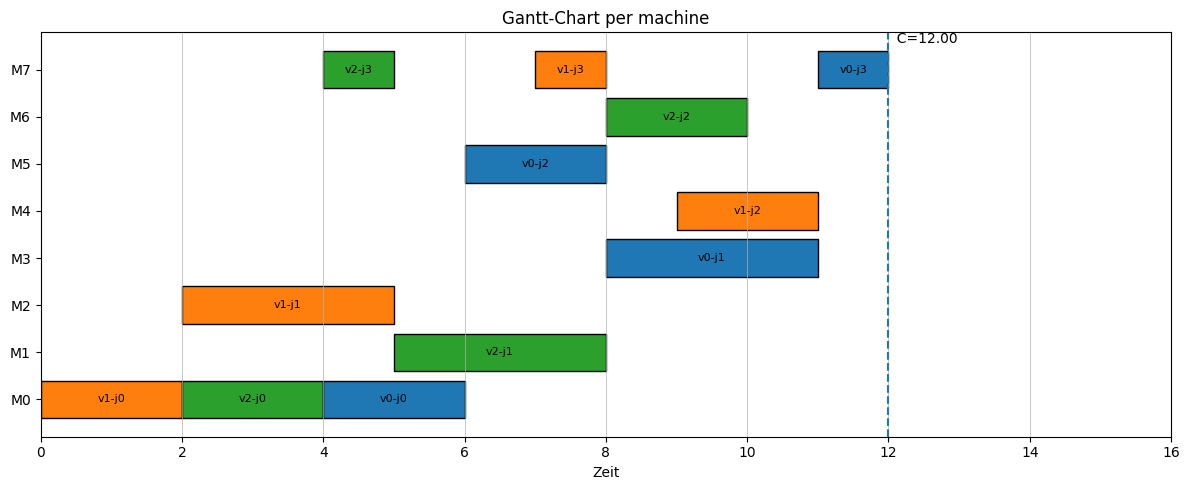

In [ ]:
import matplotlib.pyplot as plt

def extract_schedule(S, Y, duration, V, J, R, T, eps=0.5):
    """Reads start time and machine from an optimal solution.."""
    sched = []  # (machine r, start t, dur, v, j)
    for v in range(V):
        for j in range(J):
            # Startzeit finden
            start = None
            for t in range(T):
                if S[v, j, t].X > eps:
                    start = t
                    break
            if start is None:
                raise RuntimeError(f"No start found for v={v}, j={j}")

            # Maschine finden
            mach = None
            for r in range(R):
                if Y[v, j, r].X > eps:
                    mach = r
                    break
            if mach is None:
                raise RuntimeError(f"No machine found for v={v}, j={j}")

            sched.append((mach, start, duration[j], v, j))
    return sched


def plot_gantt_per_machine(schedule, T, makespan=None, title="Gantt-Chart per machine"):
    # Sort machines and assign y-positions
    machines = sorted(set(r for r, _, _, _, _ in schedule))
    y_pos = {r: i for i, r in enumerate(machines)}

    # Determine variants from the schedule and assign colors
    variants = sorted(set(v for _, _, _, v, _ in schedule))
    cmap = plt.get_cmap("tab10")
    v_color = {v: cmap(i % 10) for i, v in enumerate(variants)}

    fig, ax = plt.subplots(figsize=(12, 5))

    # Draw bars
    schedule_sorted = sorted(schedule, key=lambda x: (x[0], x[1]))  # after (machine, start)
    for r, start, dur, v, j in schedule_sorted:
        y = y_pos[r]
        ax.barh(y, dur, left=start, height=0.8, edgecolor="black",color=v_color[v])
        ax.text(start + dur/2, y, f"v{v}-j{j}", va="center", ha="center", fontsize=8)

    # Axes / Layout
    ax.set_yticks([y_pos[r] for r in machines])
    ax.set_yticklabels([f"M{r}" for r in machines])
    ax.set_xlim(0, T)
    ax.set_xlabel("Zeit")
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.5)

    # Makespan-Line
    if makespan is not None:
        ax.axvline(makespan, linestyle="--")
        ax.text(makespan, len(machines)-0.5, f"  C={makespan:.2f}", va="bottom")

    plt.tight_layout()
    plt.show()


if m.status == GRB.OPTIMAL:
    schedule = extract_schedule(S, Y, duration, V, J, R, T)
    plot_gantt_per_machine(schedule, T, makespan=C.X)
else:
    print("Kein optimales Ergebnis (Status):", m.status)